In [10]:
import pandas as pd
import numpy as np
import sympy as sym
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

min : 2.89, max: 20.40, mean: 12.00
median : 12.00, stdDev : 2.00


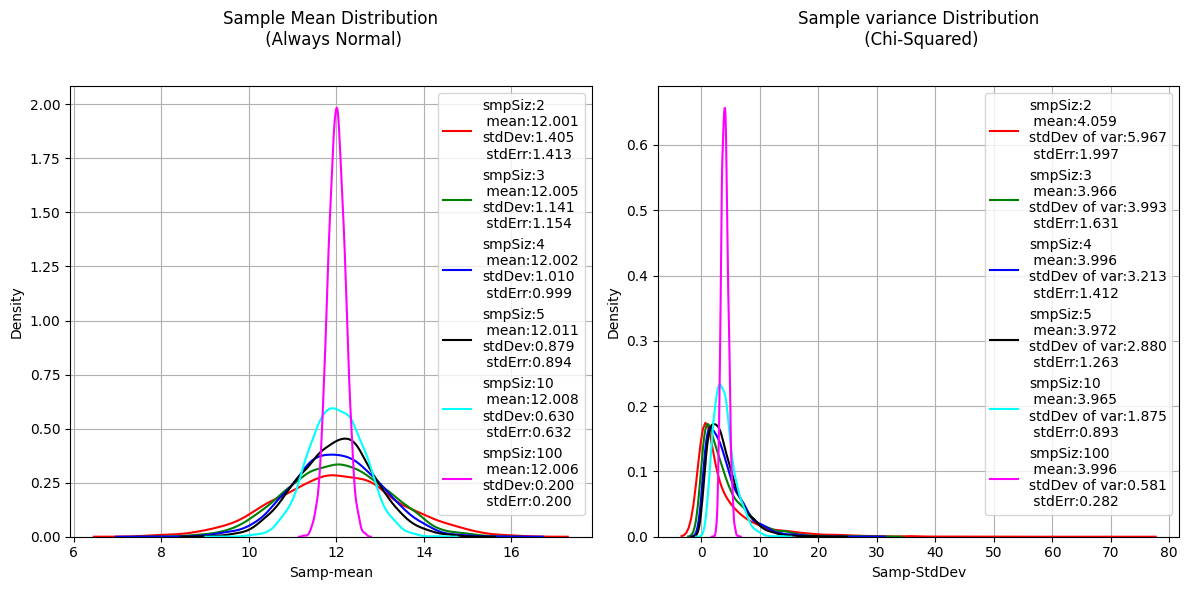

In [11]:
def get_basic_stat(arr):
    print(f"min : {np.min(arr):0.02f}, max: {np.max(arr):0.02f}, mean: {np.mean(arr):0.02f}")
    print(f"median : {np.median(arr):0.02f}, stdDev : {np.std(arr):0.02f}")
    
## Generate Population Dataset
mu_pop = 12
sigma_pop = 2
size_pop = 250000
np.random.seed() #remove seed
pop = np.random.normal(loc=mu_pop,scale = sigma_pop, size=size_pop)
mu = np.mean(pop)
sigma = np.std(pop)

get_basic_stat(pop)

res_df = pd.DataFrame()
trials = 4000
sampl_sizes = [2,3,4,5,10,100]
dis_colors = ['red','green','blue','black','cyan','magenta']
for N in sampl_sizes:    
    for n in range(trials):
        samp = np.random.choice(pop,size=N,replace=True)
        new_row = pd.DataFrame({"Trial":[n],"Samp-size":N,"Samp-mean":[np.mean(samp)],"Samp-StdDev":[np.std(samp,ddof=1)]},index=[0])
        res_df = pd.concat([res_df,new_row],ignore_index=True)

f,axes = plt.subplots(1,2,figsize=(12,6))
#sns.histplot(res_df['Samp-mean'],kde=True,ax=axes[0], label=f"mean:{np.mean(res_df['Samp-mean']):0.3f}\nstdDev:{np.std(res_df['Samp-mean']):0.3f}\n stdErr:{sigma/np.sqrt(N):0.3f}")
for N,co in zip(sampl_sizes,dis_colors):
    t_df = res_df[res_df['Samp-size'] == N]
    sns.kdeplot(t_df['Samp-mean'],ax=axes[0],color=co, label=f"smpSiz:{N}\n mean:{np.mean(t_df['Samp-mean']):0.3f}\nstdDev:{np.std(t_df['Samp-mean']):0.3f}\n stdErr:{sigma/np.sqrt(N):0.3f}")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title('Sample Mean Distribution\n (Always Normal)',pad=30)

#sns.histplot(res_df['Samp-StdDev'],kde=True,ax=axes[1],label=f"mean:{np.mean(res_df['Samp-StdDev']):0.3f}\nstdDev:{np.std(res_df['Samp-StdDev']):0.3f}")
for N,co in zip(sampl_sizes,dis_colors):
    t_df = res_df[res_df['Samp-size'] == N]
    sns.kdeplot(t_df['Samp-StdDev']**2,ax=axes[1],color=co,label=f"smpSiz:{N}\n mean:{np.mean(t_df['Samp-StdDev']**2):0.3f}\nstdDev of var:{np.std(t_df['Samp-StdDev']**2):0.3f}\n stdErr:{(sigma**2)/np.sqrt(2*N):0.3f}")
axes[1].set_title('Sample variance Distribution\n (Chi-Squared)',pad=30)
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close()

In [12]:
## Experimenting with Confidence Interval

Conf_Int = 0.99
alpha = 1-Conf_Int
z_crit = stats.norm.ppf(1-(alpha/2))
for N in sampl_sizes:
    t_df = res_df[res_df['Samp-size']==N] 
    t_df['captured']=(mu < (t_df['Samp-mean']+(z_crit*(sigma/np.sqrt(N))))) & (mu > (t_df['Samp-mean']-(z_crit*(sigma/np.sqrt(N))))) 
    captured_count = t_df[(t_df['captured']==True)]['captured'].count()
    not_captured_count = t_df[(t_df['captured']==False)]['captured'].count()
    print(f"Captured for sample size {N} %: {captured_count/t_df['captured'].count():0.3f}")

Captured for sample size 2 %: 0.988
Captured for sample size 3 %: 0.991
Captured for sample size 4 %: 0.987
Captured for sample size 5 %: 0.990
Captured for sample size 10 %: 0.989
Captured for sample size 100 %: 0.989


/var/folders/xl/cwtmpfvn2mzd77c9162xflwh0000gn/T/ipykernel_9851/774941206.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['captured']=(mu < (t_df['Samp-mean']+(z_crit*(sigma/np.sqrt(N))))) & (mu > (t_df['Samp-mean']-(z_crit*(sigma/np.sqrt(N)))))
/var/folders/xl/cwtmpfvn2mzd77c9162xflwh0000gn/T/ipykernel_9851/774941206.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['captured']=(mu < (t_df['Samp-mean']+(z_crit*(sigma/np.sqrt(N))))) & (mu > (t_df['Samp-mean']-(z_crit*(sigma/np.sqrt(N)))))
/v

In [13]:
## Z-Test
sigma = 0.133
mu = 1
Xbar = mu+(sigma/2.5)

n = 30 #samp_size
z_stat = (Xbar - mu) / (sigma/np.sqrt(n))

p = 2*(1-stats.norm.cdf(z_stat))
print(f'P-Val: {p:0.3f}, Xbar : {Xbar:0.3f}')
if(p > 0.05):
    print('Fail to Reject H0')
else:
    print('Reject H0')

P-Val: 0.028, Xbar : 1.053
Reject H0


In [14]:
2*stats.norm.sf(Xbar-mu/(sigma/np.sqrt(n))) 

np.float64(2.0)

In [15]:
stats.norm.ppf(0.025)

np.float64(-1.9599639845400545)

In [16]:
samp_sizes = [30,35,40,45,50,55,60,70,80,90,100,125,150,175,200,250,300,400,1000,2000,3000,4000,5000,8000,9000,10000,15000]
x_vals = [(np.sqrt(n)/stats.norm.ppf(0.025)) for n in range(30,1500,10)]
x_vals

[np.float64(-2.7945541950032333),
 np.float64(-3.2268732335002293),
 np.float64(-3.607753952440532),
 np.float64(-3.9520964433601993),
 np.float64(-4.268752044086233),
 np.float64(-4.563487890874748),
 np.float64(-4.840309850250343),
 np.float64(-5.102134569246538),
 np.float64(-5.351163880780574),
 np.float64(-5.589108390006467),
 np.float64(-5.817328451403679),
 np.float64(-6.036927035154623),
 np.float64(-6.248813146834432),
 np.float64(-6.4537464670004585),
 np.float64(-6.652369591099923),
 np.float64(-6.845231836312121),
 np.float64(-7.0328071642219125),
 np.float64(-7.215507904881064),
 np.float64(-7.393695425270855),
 np.float64(-7.567688534680932),
 np.float64(-7.7377701874772224),
 np.float64(-7.9041928867203985),
 np.float64(-8.067183083750573),
 np.float64(-8.226944792753956),
 np.float64(-8.383662585009699),
 np.float64(-8.537504088172467),
 np.float64(-8.688622087064878),
 np.float64(-8.837156300988553),
 np.float64(-8.983234896426328),
 np.float64(-9.126975781749495),
 np

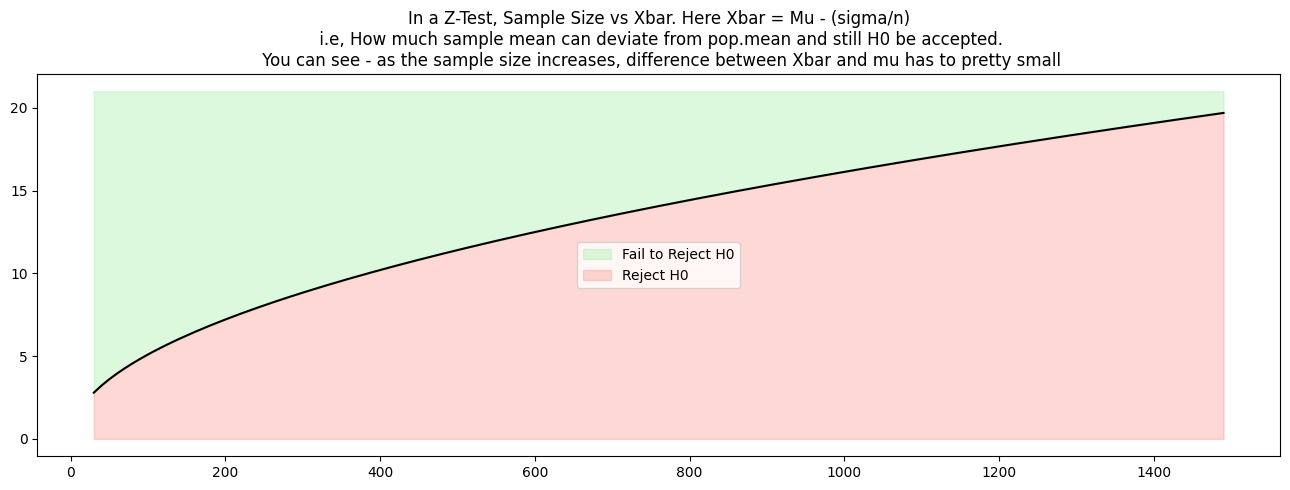

In [17]:
f= plt.figure(figsize=(13,5))
sns.lineplot(x=range(30,1500,10),y=np.abs(x_vals),color='black')
plt.fill_between(x=range(30,1500,10), y1=np.abs(x_vals), y2=21, color='lightgreen', alpha=0.3, label='Fail to Reject H0')
plt.fill_between(x=range(30,1500,10), y1=np.abs(x_vals), y2=0, color='salmon', alpha=0.3, label='Reject H0')
plt.title("In a Z-Test, Sample Size vs Xbar. Here Xbar = Mu - (sigma/n)\n i.e, How much sample mean can deviate from pop.mean and still H0 be accepted.\n You can see - as the sample size increases, difference between Xbar and mu has to pretty small")
plt.tight_layout()
plt.legend()
plt.show()